In [1]:
# Para manipulación y análisis de datos
!pip install pandas pymongo

# Para visualización de datos (gráficas)
!pip install matplotlib seaborn

# Opcional: Para análisis de sentimiento y lenguaje (muy cool para Andrés)
!pip install textblob

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from pymongo import MongoClient
import pandas as pd



In [4]:
# Conexión al servicio de MongoDB
client = MongoClient('mongodb://mongodb:27017/')
db = client['social_analytics']
collections = db.list_collection_names()
print("🗄️ Colecciones encontradas en 'social_analytics':")
for c in collections:
    # Contamos cuántos documentos hay en cada una para darle más info a Andrés
    count = db[c].count_documents({})
    print(f" - {c} ({count} documentos)")



🗄️ Colecciones encontradas en 'social_analytics':
 - tweets (163 documentos)


In [9]:
collection = db['tweets']

# Convertir la colección a DataFrame
df = pd.DataFrame(list(collection.find()))

# Verificar si cargó algo
if df.empty:
    print("⚠️ El DataFrame está vacío. ¡Revisa si el Cron ya guardó algo!")
else:
    print(f"✅ Éxito: {len(df)} registros cargados en 'df'.")
    
# Ver qué columnas existen realmente
print("Columnas disponibles:", df.columns.tolist())

# Ver una muestra de los datos
display(df)

✅ Éxito: 164 registros cargados en 'df'.
Columnas disponibles: ['_id', 'tweet_id', 'account_label', 'author', 'content', 'timestamp_detected', 'timestamp_posted']


,_id,tweet_id,account_label,author,content,timestamp_detected,timestamp_posted
0,69d6d770d4b5be3196616259,2041660134846558664,Gamer_Project,@penikmat_hujann,What the fuck just happened?,2026-04-08T22:32:16.245440,2026-04-08T22:32:16.245427
1,69d6d770d4b5be319661625a,2041795685754818669,animecol300_Project,@KoruturkBey,"In Canada, a streamer nicknamed Joker was raid...",2026-04-09T00:15:41.435439,2026-04-09T00:15:41.435428
2,69d6d770d4b5be319661625b,2041802128994275586,Gamer_Project,@Kaliza_queen,This video say a lot about nowadays society......,2026-04-08T23:50:21.907627,2026-04-08T23:50:21.907615
3,69d6d770d4b5be319661625c,analytics,animecol300_Project,@asx_capital,The Future of Real Estate: The Role of Blockch...,2026-04-09T00:45:43.534949,2026-04-09T00:45:43.534937
4,69d6d770d4b5be319661625d,2041954231817769138,Gamer_Project,@TheNetDaily,Jake Paul Got Caught,2026-04-08T22:51:53.851682,2026-04-08T22:51:53.851668
...,...,...,...,...,...,...,...
159,69d6f698d4b5be31966162f8,2041977821182951787,Gamer_Project,@chakidbest29,BREAKING NEWS : Anyone who comes across the v...,2026-04-09T00:45:12.481046,2026-04-09T00:45:12.481028
160,69d6f6add4b5be31966162f9,2042034018724803055,animecol300_Project,@elonmusk,Grok is the AI to use if you value truth,2026-04-09T00:45:32.979027,2026-04-09T00:45:32.979014
161,69d6f6add4b5be31966162fa,2041943029758525898,animecol300_Project,@UlisesDavid__,There's a rumor that Elon Musk plans to drop a...,2026-04-09T00:45:43.561503,2026-04-09T00:45:43.561491
162,69d6f6add4b5be31966162fb,2041678661862977743,animecol300_Project,@heart_jpg,,2026-04-09T00:45:43.613721,2026-04-09T00:45:43.613710


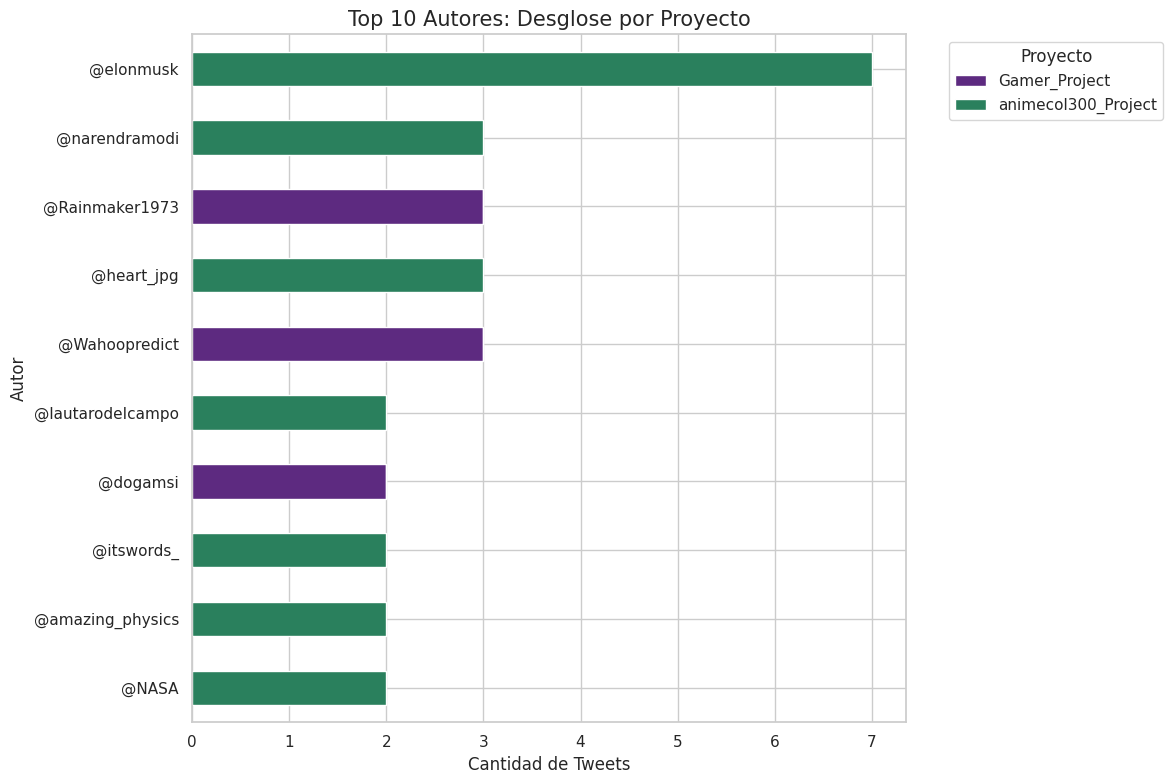

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos primero para quedarnos solo con los Top 10 autores generales
top_10_names = df['author'].value_counts().head(10).index
df_top = df[df['author'].isin(top_10_names)]

# 2. Agrupamos por autor y por cuenta, y contamos los IDs de tweets
# Esto crea la matriz de "quién publicó en qué cuenta"
pivot_df = df_top.groupby(['author', 'account_label']).size().unstack(fill_value=0)

# 3. Ordenamos para que la gráfica se vea de mayor a menor total
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('total', ascending=True).drop(columns='total')

# 4. Graficamos
# 'stacked=True' es el truco mágico para subdividir la barra
ax = pivot_df.plot(kind='barh', stacked=True, figsize=(12, 8), color=['#5d2a80', '#2a805d'])

plt.title('Top 10 Autores: Desglose por Proyecto', fontsize=15)
plt.xlabel('Cantidad de Tweets', fontsize=12)
plt.ylabel('Autor', fontsize=12)
plt.legend(title='Proyecto', bbox_to_anchor=(1.05, 1), loc='upper left') # La leyenda que pediste

plt.tight_layout()
plt.show()

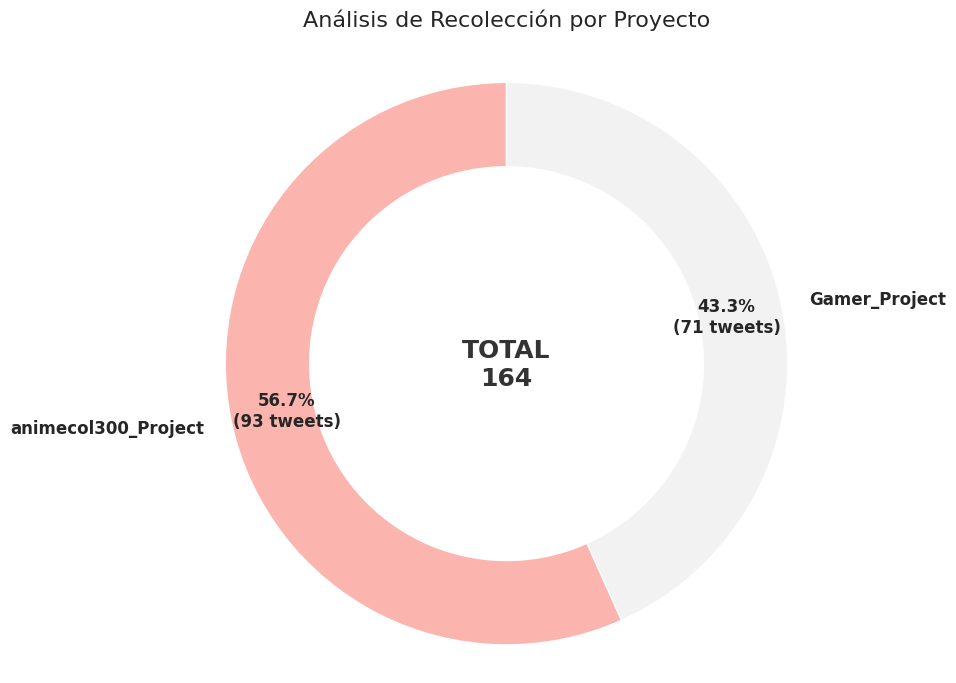

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos
conteo = df['account_label'].value_counts()
total_tweets = conteo.sum()

# 2. Generar los colores manualmente (solución al error TypeError)
# Usamos el mapa de colores 'Pastel1' basado en la cantidad de categorías que tengamos
colores = plt.get_cmap('Pastel1')(np.linspace(0, 1, len(conteo)))

# 3. Función para mostrar porcentaje y cantidad
def fmt_cantidad(pct):
    absolute = int(round(pct/100.*total_tweets))
    return f"{pct:.1f}%\n({absolute} tweets)"

plt.figure(figsize=(10, 7))

# 4. Dibujar la torta (ahora usamos 'colors' en lugar de 'cmap')
plt.pie(conteo, labels=conteo.index, autopct=fmt_cantidad, 
        startangle=90, colors=colores, pctdistance=0.80,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

# 5. Dibujar el círculo blanco central para que sea una DONA
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

# 6. Poner el gran TOTAL en el centro de la dona
plt.text(0, 0, f'TOTAL\n{total_tweets}', ha='center', va='center', 
         fontsize=18, fontweight='bold', color='#333333')

plt.title('Análisis de Recolección por Proyecto', fontsize=16, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()